# Individual Project Planning Stage 
Ray Wu - 57494734
<br>Link to Github Repository: https://github.com/raywu255/Project-Planning-Stage-Individual- 

In [1]:
library(tidyverse)
library(GGally)
library(repr)
library(tidymodels)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2

── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── t

## Broad Question: Can the variables: Age, Playtime and Session Frequency be used to predict whether a user will subscribe to the newsletter, and how do these variables vary across the different experience level classifications (Amateur, Regular, Pro, Veteran) and gender?

### Data Description

In [2]:
#Reading datasets
player_data <- read_csv("data/players.csv") |>
    mutate(experience = as.factor(experience)) |>
    mutate(gender = as.factor(gender))
    
session_data <- read_csv("data/sessions.csv") |>
    separate(col = start_time, into = c("start_date", "start_time"), sep = " ") |>
    separate(col = end_time, into = c("end_date", "end_time"), sep = " ")

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
#Basic summary statistics
num_sub <- player_data |>
    filter(subscribe == TRUE) |>
    nrow()

num_not_sub <- player_data |>
    filter(subscribe == FALSE) |>
    nrow()

percent_sub <- (num_sub / nrow(player_data))*100

player_data_stat <- player_data |>
    summarize(mean(played_hours, na.rm = TRUE), mean(Age, na.rm = TRUE)) |>
    bind_cols(nrow(player_data), nrow(session_data), num_sub, num_not_sub, percent_sub)

colnames(player_data_stat) <- c("mean_hrs_played","mean_age", 
                                "player_data_obsv", "session_data_obsv", "num_sub", "num_not_sub", "prcnt_sub")

gender <- player_data |>
    group_by(gender) |>
    summarize(n = n())

gender
player_data_stat

New names:
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`


gender,n
<fct>,<int>
Agender,2
Female,37
Male,124
Non-binary,15
Other,1
Prefer not to say,11
Two-Spirited,6


mean_hrs_played,mean_age,player_data_obsv,session_data_obsv,num_sub,num_not_sub,prcnt_sub
<dbl>,<dbl>,<int>,<int>,<int>,<int>,<dbl>
5.845918,21.13918,196,1535,144,52,73.46939


**Dataset Description**
Firstly, the player datasets were already in a tidy format, and the experience and gender varibles were changed from <chr> to <fct> datatypes, as they were categorical. Additionally, the sessions dataset was tidied by separating the date and time from start_time and end_time to four new columns, start_date, start_time, end_date, end_time. Moreover, from the gender count table, it's seen that the majority of users are male, while the other gender classifications like agender, two-spirited and non-binary are underrepresented.

From the basic statistical summaries, we can see:
- Mean total hours played: 5.85hrs
- Mean age of users: 21
- Number of observations in player_data: 196
- Number of observations in session_data: 1535
- Number of subscribed users: 144
- Number of non-subscribed users: 52
- Percentage of subscribed users: 73.47%

Potential issues with the dataset:
As the majority of users are male and other genders are underrepresented, it may make it difficult using gender as a predictor, due to uneven distributions, as there isnt enough data for agender users for example.



Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_count()`).”


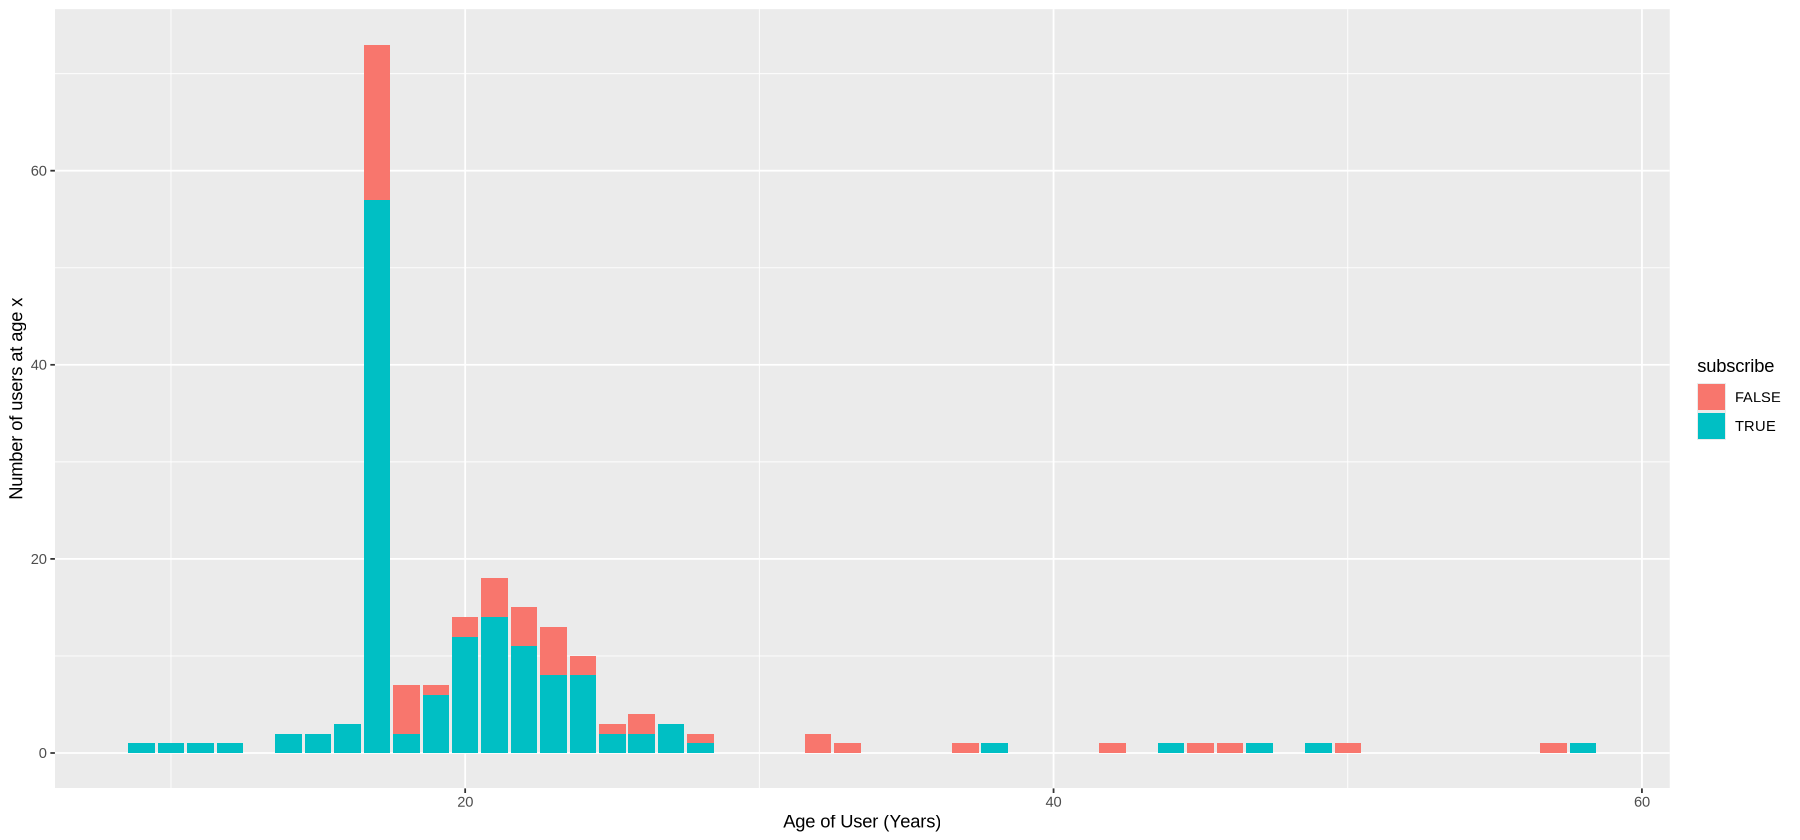

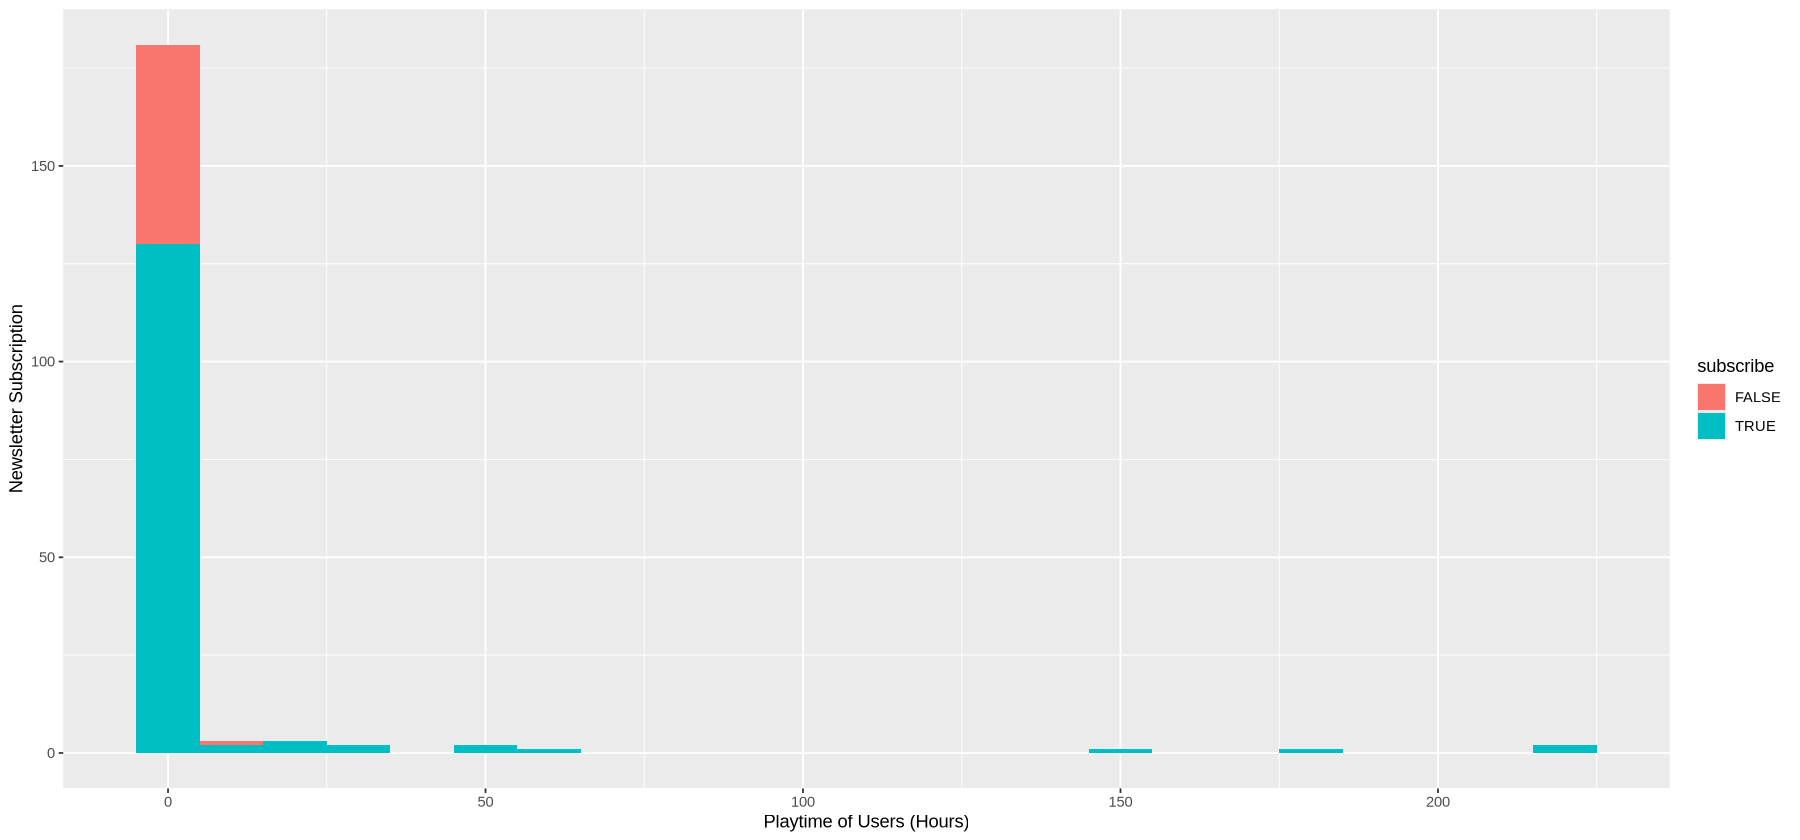

In [64]:
options(repr.plot.width = 15)
age_plot <- player_data |>
    ggplot(aes(x=Age, fill = subscribe)) +
    geom_bar() +
    labs(x="Age of User (Years)", y="Number of users at age x", color = "Subcription Status")

playtime_plot <- player_data |>
    ggplot(aes(x=played_hours, fill = subscribe)) +
    geom_histogram(binwidth=10) +
    labs(x="Playtime of Users (Hours)", y="Newsletter Subscription")

age_plot
playtime_plot